# 01. 裸 Circuit、本地模拟与结果可视化

从空 `Circuit` 构造 Bell 态，导出 OriginIR / OpenQASM 2.0，使用本地模拟器得到概率分布并画图。


In [1]:
import math
import pathlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np

from uniqc import Circuit
from uniqc.simulator import OriginIR_Simulator


def probability_dict(values):
    if isinstance(values, dict):
        total = sum(values.values()) or 1
        return {format(int(k), "b") if isinstance(k, int) else str(k): v / total for k, v in values.items()}
    n = int(math.log2(len(values))) if values else 0
    return {format(i, f"0{n}b"): float(p) for i, p in enumerate(values) if abs(float(p)) > 1e-12}


def plot_probs(probs, title):
    labels = list(probs)
    values = [probs[k] for k in labels]
    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.bar(labels, values, color="#3267a8")
    ax.set_ylim(0, max(1.0, max(values, default=0) * 1.2))
    ax.set_xlabel("bitstring")
    ax.set_ylabel("probability")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()


OriginIR:
QINIT 2
CREG 2
H q[0]
CNOT q[0], q[1]
MEASURE q[0], c[0]
MEASURE q[1], c[1]

QASM header:
OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0], q[1];
probabilities: {'00': 0.4999999999999999, '11': 0.4999999999999999}


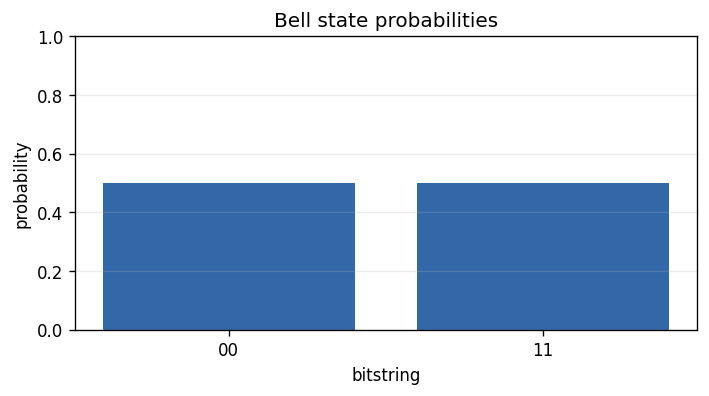

In [2]:
circuit = Circuit()
circuit.h(0)
circuit.cnot(0, 1)
circuit.measure(0, 1)

print("OriginIR:")
print(circuit.originir)
print("QASM header:")
print("\n".join(circuit.qasm.splitlines()[:6]))

sim = OriginIR_Simulator()
probs = probability_dict(sim.simulate_pmeasure(circuit.originir))
print("probabilities:", probs)
plot_probs(probs, "Bell state probabilities")
